In [2]:
!pip install -U -q protobuf tensorflow-datasets tensorflow-metadata

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 340.4/340.4 kB 3.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 7.36.0 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.36.0 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.36.0 which is incompatible.


In [2]:
!pip install -U -q importlib_resources

In [2]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt


TF version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.NKUYQD_4.0.0/oxford_iiit_pet-train.tfrecord-[0-…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.NKUYQD_4.0.0/oxford_iiit_pet-test.tfrecord-[0-9…

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.
Number of classes (breeds): 37
Train+val size: 3680
Test size: 3669
Final train size: 2944


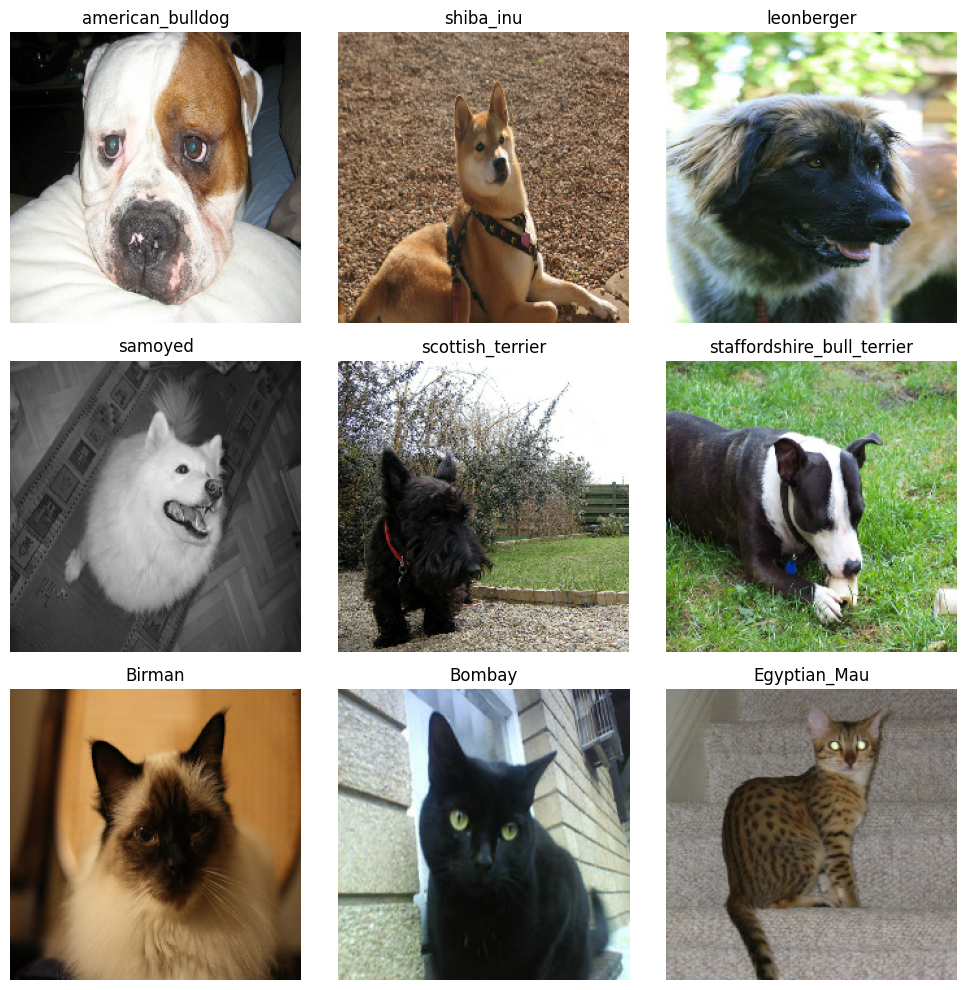

In [1]:
# ============================================================
# CS3807 - Experiment 5: Setup
# ============================================================
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt

print("TF version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 42

# ---- Load Oxford-IIIT Pet dataset ----
(ds_train_full, ds_test), ds_info = tfds.load(
    'oxford_iiit_pet',
    split=['train', 'test'],
    with_info=True,
    as_supervised=True   # returns (image, label) pairs
)

num_classes = ds_info.features['label'].num_classes
print("Number of classes (breeds):", num_classes)
print("Train+val size:", ds_info.splits['train'].num_examples)
print("Test size:", ds_info.splits['test'].num_examples)

# ---- Split train_full into train/validation (80/20) ----
train_size = int(0.8 * ds_info.splits['train'].num_examples)

ds_train_full = ds_train_full.shuffle(1000, seed=SEED)
ds_train = ds_train_full.take(train_size)
ds_val = ds_train_full.skip(train_size)

print("Final train size:", train_size)

# ---- Preprocessing function ----
def preprocess(image, label, augment=False):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    if augment:
        image = tf.image.random_flip_left_right(image)
    # MobileNetV2 preprocessing: scales pixels to [-1, 1]
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    label = tf.one_hot(label, num_classes)
    return image, label

def make_pipeline(ds, shuffle=False, augment=False):
    if shuffle:
        ds = ds.shuffle(1000, seed=SEED)
    ds = ds.map(lambda x, y: preprocess(x, y, augment), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_pipeline(ds_train, shuffle=True, augment=True)
val_ds   = make_pipeline(ds_val)
test_ds  = make_pipeline(ds_test)

# ---- Sanity check: visualize a batch ----
class_names = ds_info.features['label'].names

for images, labels in train_ds.take(1):
    plt.figure(figsize=(10, 10))
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        img = (images[i].numpy() + 1) / 2.0  # undo [-1,1] scaling for display
        plt.imshow(img)
        label_idx = np.argmax(labels[i].numpy())
        plt.title(class_names[label_idx])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

In [2]:
# ============================================================
# Task 2: Weight Initialization Comparison
# ============================================================
from tensorflow.keras import layers, models, initializers
import time

EPOCHS_INIT = 10  # keep modest for comparison runs; bump up later if time allows

def build_model(init_name):
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False  # feature extraction only for this comparison

    if init_name == 'zero':
        kernel_init = initializers.Zeros()
    elif init_name == 'random':
        kernel_init = initializers.RandomNormal(mean=0.0, stddev=0.05, seed=SEED)
    elif init_name == 'xavier':
        kernel_init = initializers.GlorotUniform(seed=SEED)
    elif init_name == 'he':
        kernel_init = initializers.HeNormal(seed=SEED)
    else:
        raise ValueError(init_name)

    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu', kernel_initializer=kernel_init)(x)
    outputs = layers.Dense(num_classes, activation='softmax', kernel_initializer=kernel_init)(x)
    model = models.Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

init_methods = ['zero', 'random', 'xavier', 'he']
init_histories = {}

for method in init_methods:
    print(f"\n{'='*50}\nTraining with {method.upper()} initialization\n{'='*50}")
    tf.keras.backend.clear_session()
    model = build_model(method)
    start = time.time()
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS_INIT,
        verbose=1
    )
    elapsed = time.time() - start
    init_histories[method] = {'history': history.history, 'time': elapsed}
    print(f"{method} took {elapsed:.1f}s")


Training with ZERO initialization
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 41s 197ms/step - accuracy: 0.0258 - loss: 3.6113 - val_accuracy: 0.0258 - val_loss: 3.6108
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 149ms/step - accuracy: 0.0251 - loss: 3.6112 - val_accuracy: 0.0177 - val_loss: 3.6115
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 148ms/step - accuracy: 0.0255 - loss: 3.6113 - val_accuracy: 0.0204 - val_loss: 3.6116
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 146ms/step - accuracy: 0.0275 - loss: 3.6112 - val_accuracy: 0.0217 - val_loss: 3.6111
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 146ms/step - accuracy: 0.0255 - loss: 3.6110 - val_accuracy: 0.0204 - val_loss: 3.6119
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 145ms/step - accuracy: 0.0262 - loss: 3.6112 - val_accuracy: 0.0177 - val_loss: 3.6123
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 169ms/step - accuracy: 0.0262 - loss: 3.6113 - val_accuracy: 0.0258 - val_loss: 3.6117
Epoch 8/10
92

In [3]:
# ---- Plot 1: Training Loss vs Epoch (all initializations) ----
plt.figure(figsize=(8, 5))
for method in init_methods:
    plt.plot(init_histories[method]['history']['loss'], label=method)
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Plot 1: Training Loss vs Epoch (Weight Initialization)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('plot1_init_loss.eps', dpi=150, bbox_inches='tight')
plt.show()

# ---- Plot 2: Validation Accuracy vs Epoch (all initializations) ----
plt.figure(figsize=(8, 5))
for method in init_methods:
    acc = [a * 100 for a in init_histories[method]['history']['val_accuracy']]
    plt.plot(acc, label=method)
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy (%)')
plt.title('Plot 2: Validation Accuracy vs Epoch (Weight Initialization)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('plot2_init_valacc.eps', dpi=150, bbox_inches='tight')
plt.show()

NameError: name 'init_methods' is not defined

<Figure size 800x500 with 0 Axes>

In [4]:
# ============================================================
# Task 3: Regularization Comparison
# ============================================================
from tensorflow.keras import regularizers

EPOCHS_REG = 20  # longer run so overfitting has room to show up

def build_reg_model(reg_type):
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False

    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)

    if reg_type == 'none':
        x = layers.Dense(128, activation='relu')(x)
    elif reg_type == 'l2':
        x = layers.Dense(128, activation='relu',
                          kernel_regularizer=regularizers.l2(1e-3))(x)
    elif reg_type == 'dropout':
        x = layers.Dense(128, activation='relu')(x)
        x = layers.Dropout(0.5)(x)
    elif reg_type == 'batchnorm':
        x = layers.Dense(128, activation='relu')(x)
        x = layers.BatchNormalization()(x)
    else:
        raise ValueError(reg_type)

    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

reg_types = ['none', 'l2', 'dropout', 'batchnorm']
reg_histories = {}

for reg in reg_types:
    print(f"\n{'='*50}\nTraining with regularization: {reg.upper()}\n{'='*50}")
    tf.keras.backend.clear_session()
    model = build_reg_model(reg)
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS_REG,
        verbose=1
    )
    reg_histories[reg] = history.history


Training with regularization: NONE
Epoch 1/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 32s 203ms/step - accuracy: 0.7272 - loss: 1.0481 - val_accuracy: 0.9035 - val_loss: 0.3199
Epoch 2/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 31s 149ms/step - accuracy: 0.9280 - loss: 0.2523 - val_accuracy: 0.9416 - val_loss: 0.2119
Epoch 3/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 152ms/step - accuracy: 0.9429 - loss: 0.1754 - val_accuracy: 0.9511 - val_loss: 0.1489
Epoch 4/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 155ms/step - accuracy: 0.9732 - loss: 0.1017 - val_accuracy: 0.9783 - val_loss: 0.0866
Epoch 5/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 157ms/step - accuracy: 0.9837 - loss: 0.0698 - val_accuracy: 0.9837 - val_loss: 0.0758
Epoch 6/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 170ms/step - accuracy: 0.9888 - loss: 0.0510 - val_accuracy: 0.9864 - val_loss: 0.0620
Epoch 7/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 150ms/step - accuracy: 0.9932 - loss: 0.0369 - val_accuracy: 0.9905 - val_loss: 0.0449
Epoch 8/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 148ms/step - accura

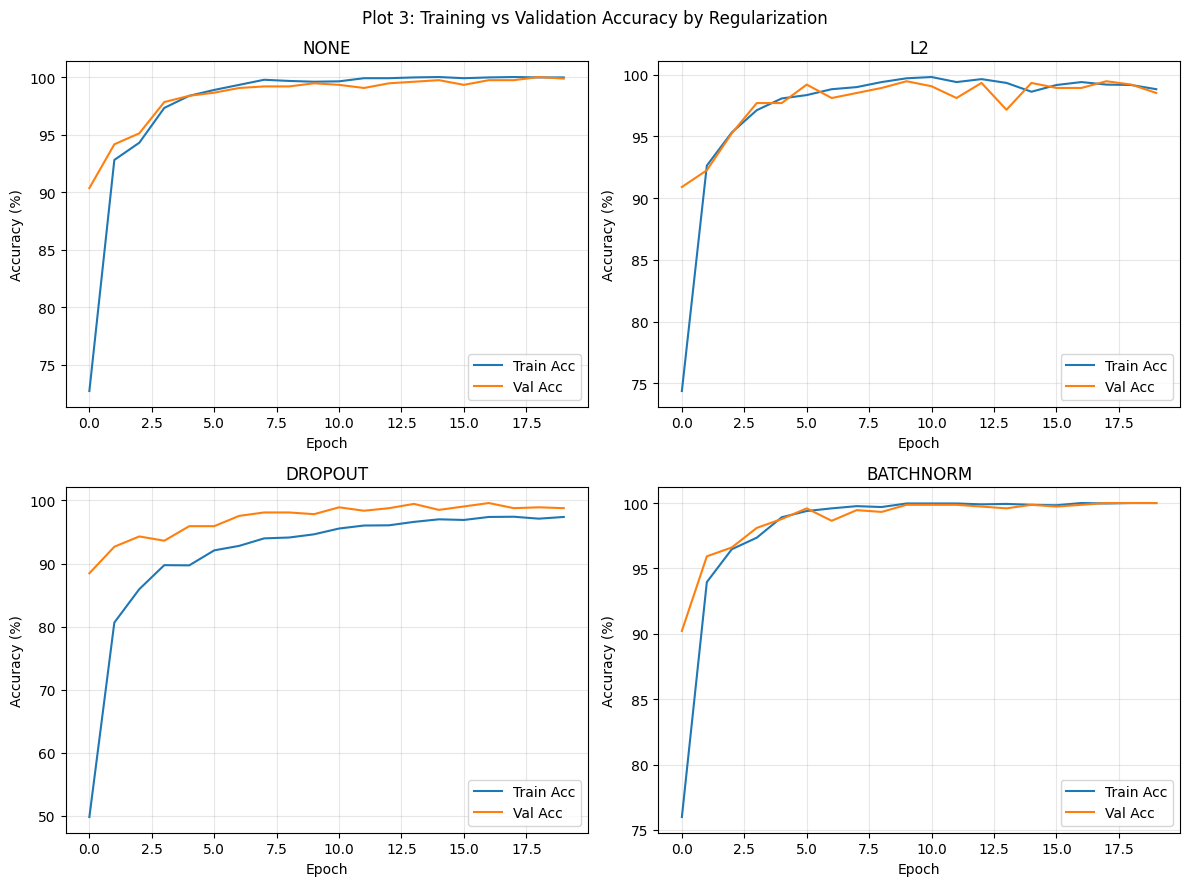

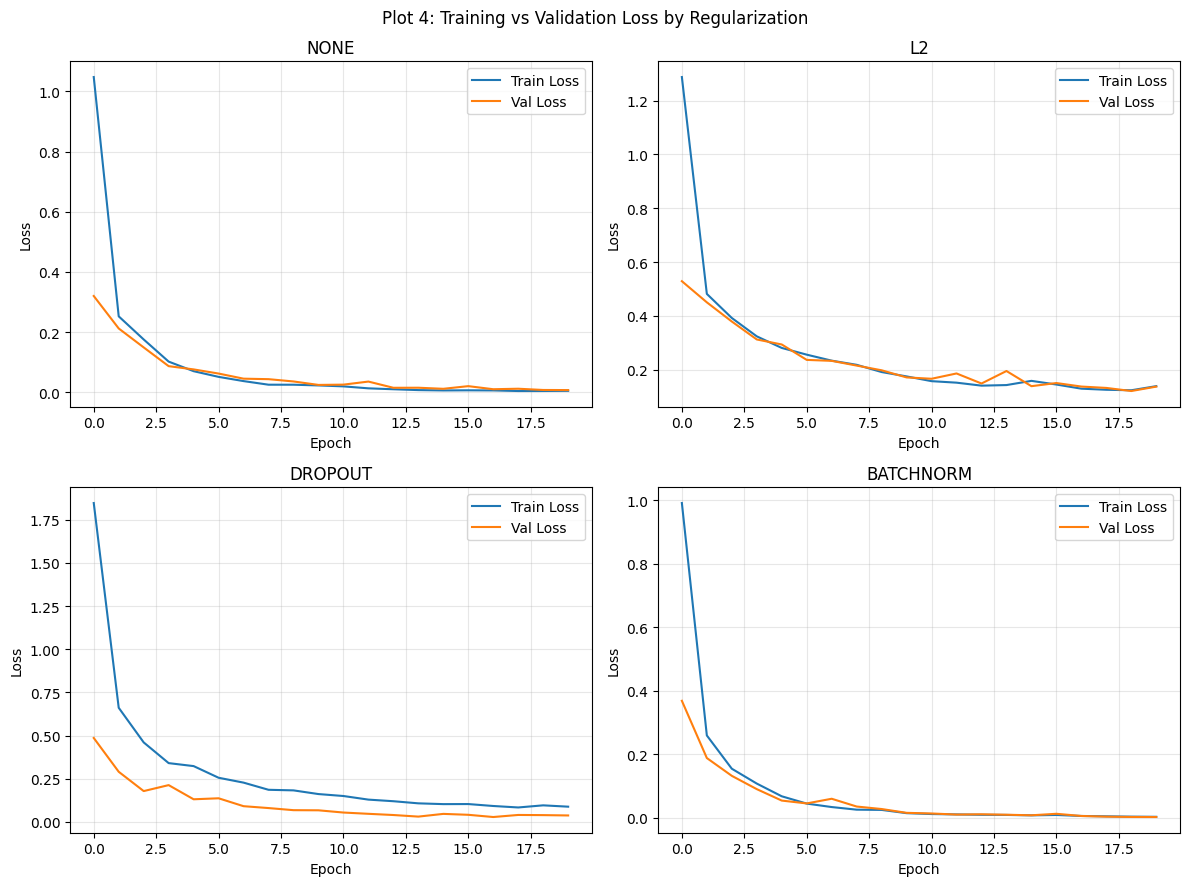

Config      Final Train Acc   Final Val Acc   Gap     
none        99.97             99.86           0.10    
l2          98.81             98.51           0.31    
dropout     97.38             98.78           -1.39   
batchnorm   100.00            100.00          0.00    


In [5]:
# ---- Plot 3: Training and Validation Accuracy vs Epoch ----
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()
for i, reg in enumerate(reg_types):
    h = reg_histories[reg]
    axes[i].plot([a*100 for a in h['accuracy']], label='Train Acc')
    axes[i].plot([a*100 for a in h['val_accuracy']], label='Val Acc')
    axes[i].set_title(f'{reg.upper()}')
    axes[i].set_xlabel('Epoch')
    axes[i].set_ylabel('Accuracy (%)')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)
plt.suptitle('Plot 3: Training vs Validation Accuracy by Regularization')
plt.tight_layout()
plt.savefig('plot3_reg_accuracy.eps', dpi=150, bbox_inches='tight')
plt.show()

# ---- Plot 4: Training and Validation Loss vs Epoch ----
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()
for i, reg in enumerate(reg_types):
    h = reg_histories[reg]
    axes[i].plot(h['loss'], label='Train Loss')
    axes[i].plot(h['val_loss'], label='Val Loss')
    axes[i].set_title(f'{reg.upper()}')
    axes[i].set_xlabel('Epoch')
    axes[i].set_ylabel('Loss')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)
plt.suptitle('Plot 4: Training vs Validation Loss by Regularization')
plt.tight_layout()
plt.savefig('plot4_reg_loss.', dpi=150, bbox_inches='tight')
plt.show()

# ---- Generalization gap summary table ----
print(f"{'Config':<12}{'Final Train Acc':<18}{'Final Val Acc':<16}{'Gap':<8}")
for reg in reg_types:
    h = reg_histories[reg]
    train_acc = h['accuracy'][-1] * 100
    val_acc = h['val_accuracy'][-1] * 100
    print(f"{reg:<12}{train_acc:<18.2f}{val_acc:<16.2f}{train_acc-val_acc:<8.2f}")

In [6]:
# ============================================================
# Task 4a: Batch Normalization - Numerical Verification
# ============================================================
x = np.array([2, 4, 6, 8], dtype=np.float32)

mu_B = np.mean(x)
var_B = np.var(x)  # population variance (divides by m, matches the doc's formula)
epsilon = 1e-8

x_hat = (x - mu_B) / np.sqrt(var_B + epsilon)

gamma, beta = 1.0, 0.0
y = gamma * x_hat + beta

print(f"Batch mean (μ_B): {mu_B}")
print(f"Batch variance (σ²_B): {var_B}")
print(f"Std dev: {np.sqrt(var_B):.3f}")
print(f"Normalized (x̂): {x_hat}")
print(f"Output (γ=1, β=0): {y}")

# Cross-check against Keras's own BatchNormalization layer
bn_layer = layers.BatchNormalization()
x_reshaped = x.reshape(1, 4, 1)  # (batch, features, channels) - toy shape
bn_out = bn_layer(x_reshaped, training=True)
print("\nKeras BN layer output (sanity check):", bn_out.numpy().flatten())

Batch mean (μ_B): 5.0
Batch variance (σ²_B): 5.0
Std dev: 2.236
Normalized (x̂): [-1.3416407 -0.4472136  0.4472136  1.3416407]
Output (γ=1, β=0): [-1.3416407 -0.4472136  0.4472136  1.3416407]

Keras BN layer output (sanity check): [-1.3415067  -0.44716895  0.44716883  1.3415065 ]



Training without_bn
Epoch 1/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 31s 198ms/step - accuracy: 0.7368 - loss: 1.0529 - val_accuracy: 0.9049 - val_loss: 0.3075
Epoch 2/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 153ms/step - accuracy: 0.9239 - loss: 0.2478 - val_accuracy: 0.9606 - val_loss: 0.1797
Epoch 3/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 147ms/step - accuracy: 0.9511 - loss: 0.1669 - val_accuracy: 0.9755 - val_loss: 0.1178
Epoch 4/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 183ms/step - accuracy: 0.9674 - loss: 0.1157 - val_accuracy: 0.9823 - val_loss: 0.0986
Epoch 5/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 147ms/step - accuracy: 0.9847 - loss: 0.0675 - val_accuracy: 0.9864 - val_loss: 0.0657
Epoch 6/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 25s 179ms/step - accuracy: 0.9908 - loss: 0.0476 - val_accuracy: 0.9864 - val_loss: 0.0549
Epoch 7/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 37s 150ms/step - accuracy: 0.9888 - loss: 0.0480 - val_accuracy: 0.9918 - val_loss: 0.0457
Epoch 8/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 150ms/step - accuracy: 0.9980 - lo

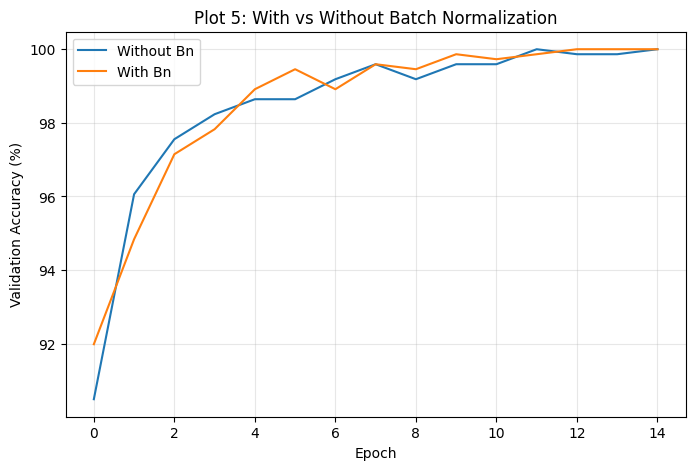

In [7]:
# ============================================================
# Task 4b: Plot 5 - With vs Without Batch Normalization
# ============================================================
EPOCHS_BN = 15

def build_bn_compare_model(use_bn):
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False

    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    if use_bn:
        x = layers.BatchNormalization()(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

bn_histories = {}
for use_bn, label in [(False, 'without_bn'), (True, 'with_bn')]:
    print(f"\n{'='*50}\nTraining {label}\n{'='*50}")
    tf.keras.backend.clear_session()
    model = build_bn_compare_model(use_bn)
    history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_BN, verbose=1)
    bn_histories[label] = history.history

# ---- Plot 5 ----
plt.figure(figsize=(8, 5))
for label in ['without_bn', 'with_bn']:
    acc = [a * 100 for a in bn_histories[label]['val_accuracy']]
    plt.plot(acc, label=label.replace('_', ' ').title())
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy (%)')
plt.title('Plot 5: With vs Without Batch Normalization')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('plot5_bn_comparison.eps', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# ============================================================
# Task 5: Optimizer Comparison
# ============================================================
EPOCHS_OPT = 15

def build_opt_model():
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False

    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    return model

optimizers_dict = {
    'SGD': tf.keras.optimizers.SGD(learning_rate=1e-3),
    'Momentum': tf.keras.optimizers.SGD(learning_rate=1e-3, momentum=0.9),
    'RMSProp': tf.keras.optimizers.RMSprop(learning_rate=1e-3),
    'Adam': tf.keras.optimizers.Adam(learning_rate=1e-3),
}

opt_histories = {}
opt_summary = []

for name, opt in optimizers_dict.items():
    print(f"\n{'='*50}\nTraining with {name}\n{'='*50}")
    tf.keras.backend.clear_session()
    model = build_opt_model()
    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

    start = time.time()
    history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_OPT, verbose=1)
    elapsed = time.time() - start

    val_acc = history.history['val_accuracy']
    best_val_acc = max(val_acc)
    # epoch to converge: first epoch reaching within 1% of best val acc
    converge_epoch = next(i for i, a in enumerate(val_acc) if a >= best_val_acc - 0.01) + 1

    opt_histories[name] = history.history
    opt_summary.append({
        'Optimizer': name,
        'Final Loss': history.history['loss'][-1],
        'Best Val Accuracy': best_val_acc * 100,
        'Epoch to Converge': converge_epoch,
        'Time (s)': elapsed
    })


Training with SGD
Epoch 1/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 38s 250ms/step - accuracy: 0.0353 - loss: 3.9717 - val_accuracy: 0.0503 - val_loss: 3.6371
Epoch 2/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 151ms/step - accuracy: 0.0465 - loss: 3.7432 - val_accuracy: 0.0897 - val_loss: 3.4996
Epoch 3/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 149ms/step - accuracy: 0.0683 - loss: 3.5734 - val_accuracy: 0.1250 - val_loss: 3.3457
Epoch 4/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 170ms/step - accuracy: 0.0890 - loss: 3.4372 - val_accuracy: 0.1644 - val_loss: 3.2279
Epoch 5/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 153ms/step - accuracy: 0.1026 - loss: 3.3254 - val_accuracy: 0.2120 - val_loss: 3.1354
Epoch 6/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 154ms/step - accuracy: 0.1413 - loss: 3.1989 - val_accuracy: 0.2867 - val_loss: 3.0056
Epoch 7/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 151ms/step - accuracy: 0.1756 - loss: 3.0914 - val_accuracy: 0.3261 - val_loss: 2.9192
Epoch 8/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 154ms/step - accuracy: 0.1940 - loss

In [1]:
# ---- Plot 6: Training Loss vs Epoch ----
plt.figure(figsize=(8, 5))
for name in optimizers_dict:
    plt.plot(opt_histories[name]['loss'], label=name)
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Plot 6: Training Loss vs Epoch (Optimizers)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('plot6_opt_loss.eps', dpi=150, bbox_inches='tight')
plt.show()

# ---- Plot 7: Validation Accuracy vs Epoch ----
plt.figure(figsize=(8, 5))
for name in optimizers_dict:
    acc = [a * 100 for a in opt_histories[name]['val_accuracy']]
    plt.plot(acc, label=name)
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy (%)')
plt.title('Plot 7: Validation Accuracy vs Epoch (Optimizers)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('plot7_opt_valacc.eps', dpi=150, bbox_inches='tight')
plt.show()

# ---- Fill in the required table from the doc ----
import pandas as pd
opt_table = pd.DataFrame(opt_summary)
opt_table = opt_table[['Optimizer', 'Final Loss', 'Best Val Accuracy', 'Epoch to Converge', 'Time (s)']]
print(opt_table.to_string(index=False))
opt_table.to_csv('optimizer_comparison_table.csv', index=False)

NameError: name 'plt' is not defined


--- Learning Rate: 0.001 ---
Epoch 1/12
92/92 ━━━━━━━━━━━━━━━━━━━━ 34s 199ms/step - accuracy: 0.6471 - loss: 1.3446 - val_accuracy: 0.9103 - val_loss: 0.3148
Epoch 2/12
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 150ms/step - accuracy: 0.8791 - loss: 0.3995 - val_accuracy: 0.9266 - val_loss: 0.2222
Epoch 3/12
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 149ms/step - accuracy: 0.9161 - loss: 0.2604 - val_accuracy: 0.9511 - val_loss: 0.1672
Epoch 4/12
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 147ms/step - accuracy: 0.9280 - loss: 0.2121 - val_accuracy: 0.9579 - val_loss: 0.1299
Epoch 5/12
92/92 ━━━━━━━━━━━━━━━━━━━━ 22s 148ms/step - accuracy: 0.9562 - loss: 0.1546 - val_accuracy: 0.9606 - val_loss: 0.1108
Epoch 6/12
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 146ms/step - accuracy: 0.9609 - loss: 0.1309 - val_accuracy: 0.9728 - val_loss: 0.0901
Epoch 7/12
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 150ms/step - accuracy: 0.9674 - loss: 0.1105 - val_accuracy: 0.9810 - val_loss: 0.0646
Epoch 8/12
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 150ms/step - accuracy: 0.

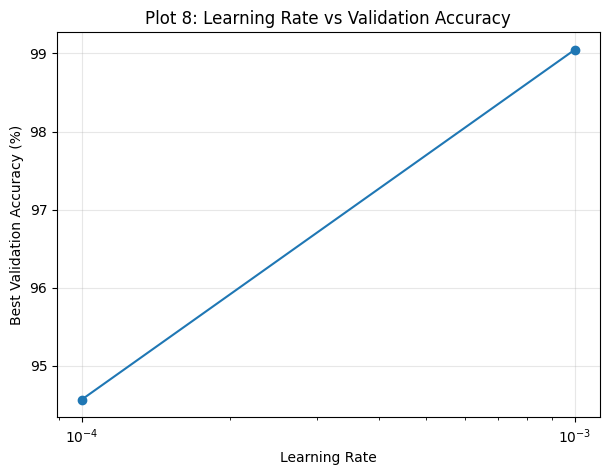

In [10]:
# ============================================================
# Task 6: Hyperparameter Tuning
# ============================================================
EPOCHS_HP = 12

def build_hp_model(dropout_rate):
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False
    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs, outputs)

# ---- Plot 8: Learning Rate vs Validation Accuracy ----
learning_rates = [0.001, 0.0001]
lr_results = {}

for lr in learning_rates:
    print(f"\n--- Learning Rate: {lr} ---")
    tf.keras.backend.clear_session()
    model = build_hp_model(dropout_rate=0.25)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_HP, verbose=1)
    lr_results[lr] = max(history.history['val_accuracy']) * 100

plt.figure(figsize=(7, 5))
plt.plot(list(lr_results.keys()), list(lr_results.values()), marker='o')
plt.xlabel('Learning Rate')
plt.ylabel('Best Validation Accuracy (%)')
plt.title('Plot 8: Learning Rate vs Validation Accuracy')
plt.xscale('log')
plt.grid(True, alpha=0.3)
plt.savefig('plot8_lr_valacc.eps', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ---- Plot 9: Batch Size vs Validation Accuracy ----
batch_sizes = [16, 32, 64]
bs_results = {}

for bs in batch_sizes:
    print(f"\n--- Batch Size: {bs} ---")
    train_ds_bs = ds_train.shuffle(1000, seed=SEED).map(
        lambda x, y: preprocess(x, y, augment=True), num_parallel_calls=tf.data.AUTOTUNE
    ).batch(bs).prefetch(tf.data.AUTOTUNE)
    val_ds_bs = ds_val.map(
        lambda x, y: preprocess(x, y, augment=False), num_parallel_calls=tf.data.AUTOTUNE
    ).batch(bs).prefetch(tf.data.AUTOTUNE)

    tf.keras.backend.clear_session()
    model = build_hp_model(dropout_rate=0.25)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    history = model.fit(train_ds_bs, validation_data=val_ds_bs, epochs=EPOCHS_HP, verbose=1)
    bs_results[bs] = max(history.history['val_accuracy']) * 100

plt.figure(figsize=(7, 5))
plt.plot(list(bs_results.keys()), list(bs_results.values()), marker='o')
plt.xlabel('Batch Size')
plt.ylabel('Best Validation Accuracy (%)')
plt.title('Plot 9: Batch Size vs Validation Accuracy')
plt.grid(True, alpha=0.3)
plt.savefig('plot9_batchsize_valacc.eps', dpi=150, bbox_inches='tight')
plt.show()


--- Batch Size: 16 ---
Epoch 1/12
184/184 ━━━━━━━━━━━━━━━━━━━━ 41s 104ms/step - accuracy: 0.6851 - loss: 1.1721 - val_accuracy: 0.9117 - val_loss: 0.3234
Epoch 2/12
184/184 ━━━━━━━━━━━━━━━━━━━━ 19s 79ms/step - accuracy: 0.8899 - loss: 0.3688 - val_accuracy: 0.9361 - val_loss: 0.1978
Epoch 3/12
184/184 ━━━━━━━━━━━━━━━━━━━━ 18s 78ms/step - accuracy: 0.9219 - loss: 0.2578 - val_accuracy: 0.9647 - val_loss: 0.1431
Epoch 4/12
184/184 ━━━━━━━━━━━━━━━━━━━━ 21s 79ms/step - accuracy: 0.9419 - loss: 0.1858 - val_accuracy: 0.9620 - val_loss: 0.1186
Epoch 5/12
184/184 ━━━━━━━━━━━━━━━━━━━━ 18s 79ms/step - accuracy: 0.9586 - loss: 0.1410 - val_accuracy: 0.9755 - val_loss: 0.0812
Epoch 6/12
184/184 ━━━━━━━━━━━━━━━━━━━━ 19s 78ms/step - accuracy: 0.9613 - loss: 0.1184 - val_accuracy: 0.9769 - val_loss: 0.0783
Epoch 7/12
184/184 ━━━━━━━━━━━━━━━━━━━━ 21s 95ms/step - accuracy: 0.9694 - loss: 0.0916 - val_accuracy: 0.9851 - val_loss: 0.0555
Epoch 8/12
184/184 ━━━━━━━━━━━━━━━━━━━━ 18s 78ms/step - accuracy: